# Collections → Skalar / GC sharing waterfall

Visualizes how each dollar of **collections** is transformed:

`collections → ×margin → Reference Income → ×sharing → theoretical sharing → cap-truncate → effective Skalar share (S̃)`, and then S̃ is **split** between the **GC remittance** and what **stays in Skalar**.

Two views, both from `skalar_viz` (which reuses the engine's `reference_income` / `sharing_schedule`):
1. a **waterfall** of where the portfolio's collections end up, and
2. a **cohort × calendar-period run-off triangle** (constant cohort age runs along the diagonals; the empty corner is masked).

Everything below is driven by the **Parameters** cell — edit it and re-run.

## Parameters

In [1]:
# --- knobs (papermill-compatible) ---
COMPANY = "SK011"
COHORTS = ["2026-06", "2026-07", "2026-08", "2026-09"]  # origin months
N_PERIODS = 9            # periods of life modelled per cohort
FIRST_COLLECTION = 120000.0   # first-period collections per cohort
DECAY = 0.82             # geometric decay of collections with age
SPEND = 200000.0         # origin S&M spend per cohort (sizes the return cap)
FUNDING_PCT = 0.80
SHARING_PCT = 0.80
MARGIN = 0.45
GC_LEVERAGE = 0.95       # GC senior advance fraction (sigma)
GC_CAP_MULTIPLE = 2.0    # GC entitlement ceiling = multiple x PFA

## Build the decomposition

In [2]:
from datetime import date
from decimal import Decimal

from skalar_viz import (
    build_cohort_period_matrix,
    build_waterfall_steps,
    decompose_portfolio,
    demo_deal_parameters,
    geometric_series,
    plot_cohort_matrix,
    plot_waterfall,
    synthetic_collections,
)

def D(x):
    return Decimal(str(x))

def month(label):
    year, mon = label.split("-")
    return date(int(year), int(mon), 1)

params = demo_deal_parameters(
    funding_pct=D(FUNDING_PCT), sharing_pct=D(SHARING_PCT),
    margin=D(MARGIN), gc_funding_pct=D(GC_LEVERAGE),
)

series = geometric_series(D(FIRST_COLLECTION), D(DECAY), N_PERIODS)
collections = synthetic_collections({month(c): series for c in COHORTS}, company_id=COMPANY)

f_eff = D(FUNDING_PCT) * D(SPEND)                 # effective funding per cohort
gc_cap = D(GC_CAP_MULTIPLE) * D(GC_LEVERAGE) * f_eff   # GC entitlement ceiling
fundings = {month(c): (f_eff, gc_cap) for c in COHORTS}

cells = decompose_portfolio(collections, params, fundings)
f"{len(cells)} cohort-period cells across {len(COHORTS)} cohorts"

'36 cohort-period cells across 4 cohorts'

## 1. Waterfall — where each dollar of collections goes

Milestone **totals** are drawn from the baseline; **reductions** float between them. The teal bar is the GC remittance; the green total is what Skalar keeps.

Collections                         2,219,681  [total]
Company keeps (margin)             -1,220,825  [delta]
Reference income                      998,857  [total]
Company keeps (1 - sharing)          -199,771  [delta]
Theoretical sharing                   799,085  [total]
Above return cap                      -98,925  [delta]
Effective Skalar share (S~)           700,160  [total]
Remitted to GC                       -665,152  [delta]
Skalar retained                        35,008  [total]


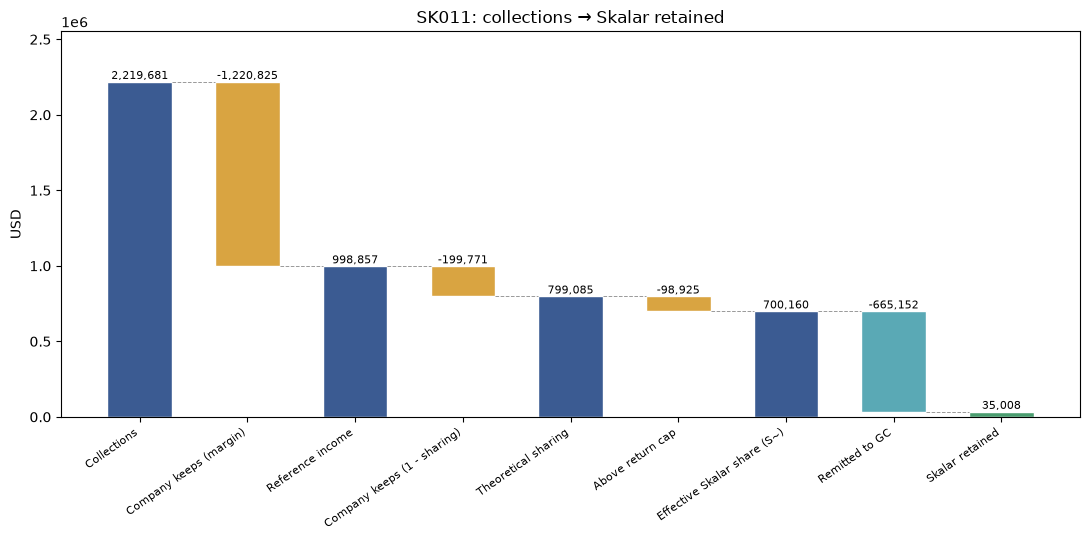

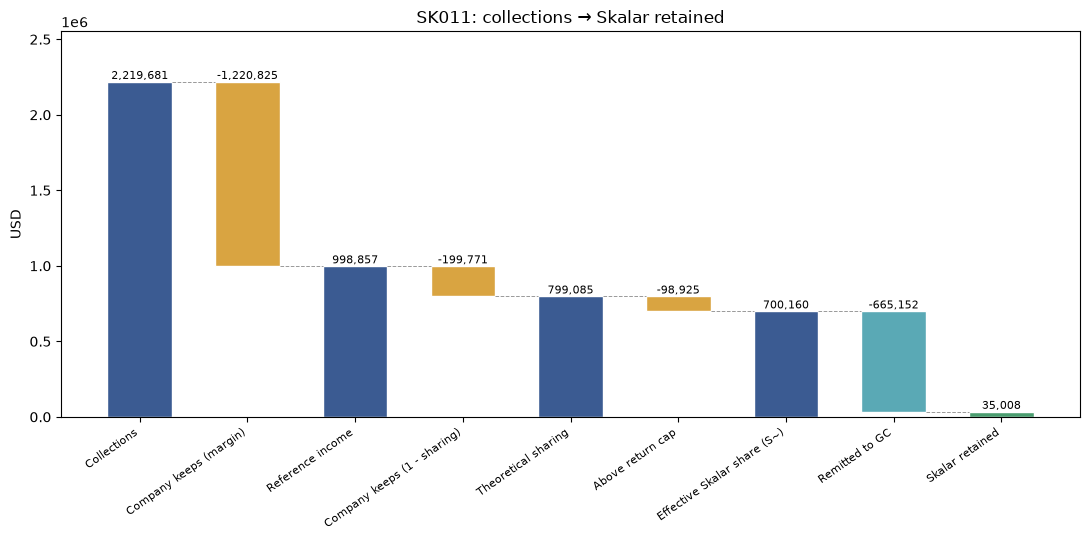

In [3]:
steps = build_waterfall_steps(cells)
for s in steps:
    print(f"{s.label:30s} {float(s.value):14,.0f}  [{s.kind.value}]")

plot_waterfall(steps, title=f"{COMPANY}: collections → Skalar retained")

## 2. Cohort × time run-off triangle

Rows are cohorts (origin month), columns are calendar periods; a cell is that cohort's value in that period. Constant **age** runs along the diagonals, and the lower-left corner (periods before a cohort exists) is masked — the classic run-off triangle.

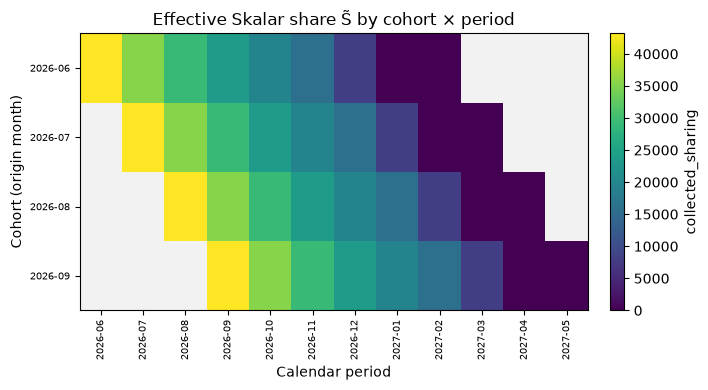

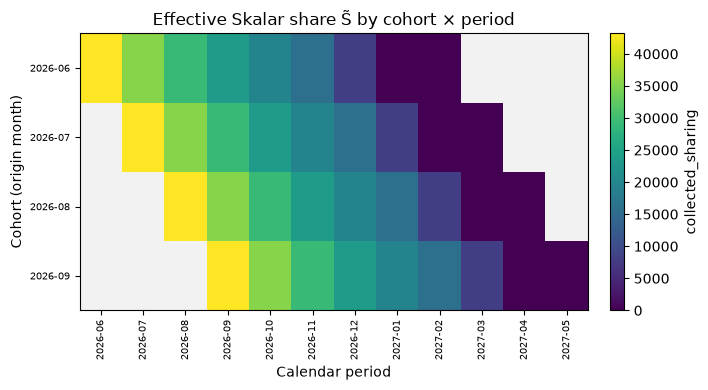

In [4]:
plot_cohort_matrix(
    build_cohort_period_matrix(cells, "collected_sharing"),
    title="Effective Skalar share S̃ by cohort × period",
)

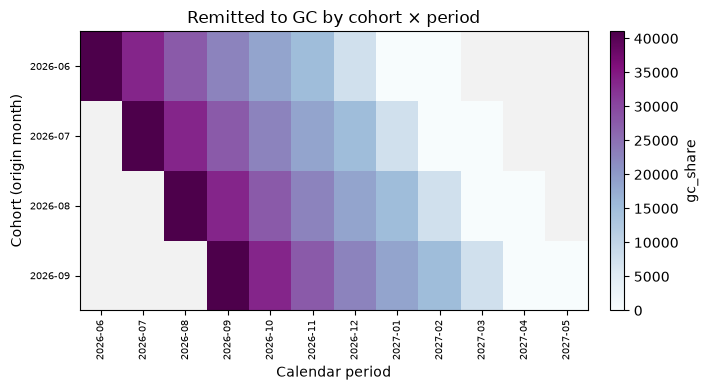

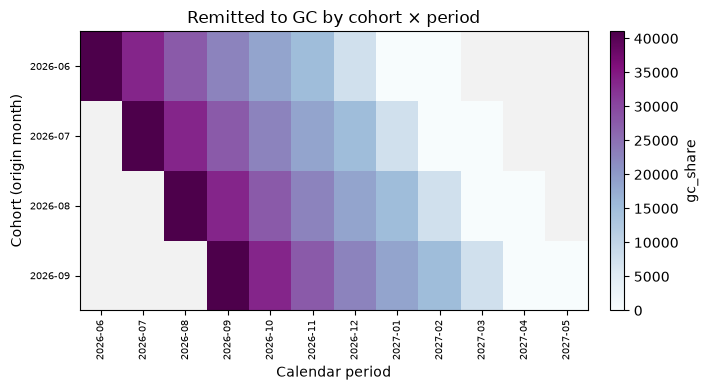

In [5]:
plot_cohort_matrix(
    build_cohort_period_matrix(cells, "gc_share"),
    title="Remitted to GC by cohort × period", cmap="BuPu",
)

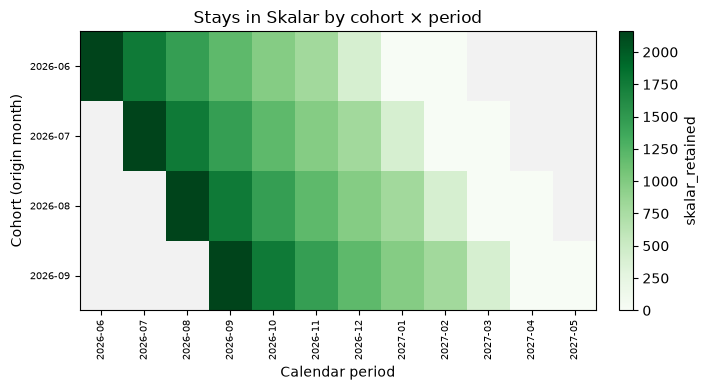

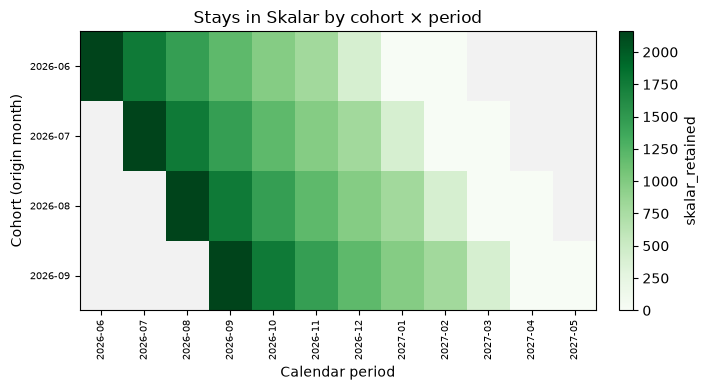

In [6]:
plot_cohort_matrix(
    build_cohort_period_matrix(cells, "skalar_retained"),
    title="Stays in Skalar by cohort × period", cmap="Greens",
)

### Notes

- Early in a cohort's life GC takes `leverage × S̃` (95%) and Skalar keeps 5%; once cumulative remittance reaches the cohort's GC cap, GC's share drops to 0 and **Skalar retains 100%** — visible as the retained-share triangle brightening on the right of each row.
- Swap `COMPANY`/`COHORTS` and point `synthetic_collections` at cached/live collections to run this on real data; the decomposition and plots are unchanged.